Red   : 1
Green : 1
Blue  : 1
NIR   : 1
GT    : 1

Total samples: 1

Only one sample is available.
80/20 train-validation split is skipped.

DATASET TEST
Image shape: torch.Size([4, 384, 384])
Mask shape : torch.Size([1, 384, 384])
Image dtype: torch.float32
Mask dtype : torch.float32
Image min  : 0.0
Image max  : 1.0
Mask values: [0.0, 1.0]

DATALOADER TEST
Batch image shape: torch.Size([1, 4, 384, 384])
Batch mask shape : torch.Size([1, 1, 384, 384])
Total patches available: 1

NOTE: Only a handful of patch(es) available (sample_tif smoke test). Visuals/statistics below are illustrative only — re-run this script once the full 38-Cloud_training dataset (8400 patches) is downloaded for a meaningful EDA.



c:\Users\USER\anaconda3\envs\geopy\lib\site-packages\rasterio\__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Saved outputs\eda_samples.png


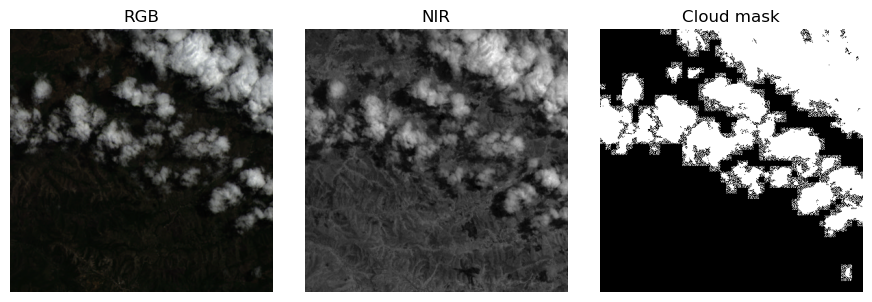

Sampled 1 patch(es)
Cloud pixel fraction : 0.360
Clear pixel fraction : 0.640
Saved outputs\eda_class_balance.png


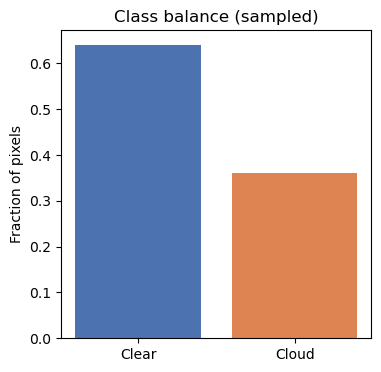


CLASS IMBALANCE NOTES
Cloud/clear balance is roughly even (cloud fraction = 0.36). Still worth checking per-scene, since some individual patches may be all-cloud or all-clear even if the overall average looks balanced.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dataset import CloudDataset, samples

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 1. VISUALIZE SAMPLE IMAGES (RGB + NIR + MASK)
# ============================================================
def show_samples(dataset, n=3):
    """Plot RGB composite, NIR band, and ground-truth mask side by side."""

    n = min(n, len(dataset))  # don't ask for more samples than exist
    idxs = np.random.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes.reshape(1, 3)  # keep 2D indexing consistent for n=1

    for row, idx in enumerate(idxs):
        image, mask = dataset[int(idx)]      # image: [4,H,W], mask: [1,H,W]
        image = image.numpy()
        mask = mask.numpy().squeeze()

        rgb = np.transpose(image[:3], (1, 2, 0))   # [H,W,3] for R,G,B
        nir = image[3]

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title("RGB")
        axes[row, 1].imshow(nir, cmap="gray")
        axes[row, 1].set_title("NIR")
        axes[row, 2].imshow(mask, cmap="gray")
        axes[row, 2].set_title("Cloud mask")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "eda_samples.png")
    plt.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")
    plt.show()          # <-- pop up / display the figure
    plt.close(fig)

# ============================================================
# 2. CLASS DISTRIBUTION (CLOUD VS NON-CLOUD PIXELS)
# ============================================================
def class_balance(dataset, n_samples=300, seed=0):
    """
    Estimate the fraction of cloud vs. clear pixels across a sample of
    patches. With few patches (e.g. the sample_tif smoke test), this
    just uses everything available.
    """
    n_samples = min(n_samples, len(dataset))
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=n_samples, replace=False)

    cloud_pixels = 0
    total_pixels = 0

    for idx in idxs:
        _, mask = dataset[int(idx)]
        m = mask.numpy()
        cloud_pixels += m.sum()
        total_pixels += m.size

    cloud_frac = cloud_pixels / total_pixels
    clear_frac = 1 - cloud_frac

    print(f"Sampled {n_samples} patch(es)")
    print(f"Cloud pixel fraction : {cloud_frac:.3f}")
    print(f"Clear pixel fraction : {clear_frac:.3f}")

    plt.figure(figsize=(4, 4))
    plt.bar(["Clear", "Cloud"], [clear_frac, cloud_frac],
             color=["#4C72B0", "#DD8452"])
    plt.ylabel("Fraction of pixels")
    plt.title("Class balance (sampled)")
    out_path = os.path.join(OUTPUT_DIR, "eda_class_balance.png")
    plt.savefig(out_path, dpi=150)
    print(f"Saved {out_path}")
    plt.show()          # <-- pop up / display the figure
    plt.close()

    return cloud_frac

# ============================================================
# 3. RUN EDA
# ============================================================
if __name__ == "__main__":

    print(f"Total patches available: {len(samples)}")

    if len(samples) < 3:
        print(
            "\nNOTE: Only a handful of patch(es) available "
            "(sample_tif smoke test). Visuals/statistics below are "
            "illustrative only — re-run this script once the full "
            "38-Cloud_training dataset (8400 patches) is downloaded "
            "for a meaningful EDA.\n"
        )

    # Use the full dataset built in dataset.py for consistency
    full_dataset = CloudDataset(samples)

    show_samples(full_dataset, n=3)
    cloud_frac = class_balance(full_dataset, n_samples=300)

    print("\n" + "=" * 50)
    print("CLASS IMBALANCE NOTES")
    print("=" * 50)
    if cloud_frac < 0.3 or cloud_frac > 0.7:
        print(
            "Class imbalance observed (cloud fraction = "
            f"{cloud_frac:.2f}). Plan to address this with:\n"
            "  - Dice loss or a BCE+Dice combo (less sensitive to\n"
            "    imbalance than plain BCE)\n"
            "  - Optionally, class-weighted BCE using the pos_weight\n"
            "    argument in BCEWithLogitsLoss\n"
            "  - Avoid naive oversampling of whole patches since\n"
            "    Landsat-8 patches often contain a mix of cloud and\n"
            "    clear regions within the same tile"
        )
    else:
        print(
            f"Cloud/clear balance is roughly even (cloud fraction = "
            f"{cloud_frac:.2f}). Still worth checking per-scene, since "
            "some individual patches may be all-cloud or all-clear "
            "even if the overall average looks balanced."
        )